In [2]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          05-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data_train = pd.read_csv("data_train.csv")


<span style="font-size: 18px;"><b>Correlatie heatmap variabelen dataset Churn</b></span>
In de figuur hieronder is een heatmap weergegeven waarbij alle variabelen uit de dataset van churndata tegen elkaar en zichzelf zijn uitgezet. In de exploratieve plots hieronder zullen we de meeste sterk correlerende variabelen tegen elkaar uitzetten met behulp van spreidingsdiagrammen. Ook zullen we enkele histogrammen en een boxplot visualiseren.

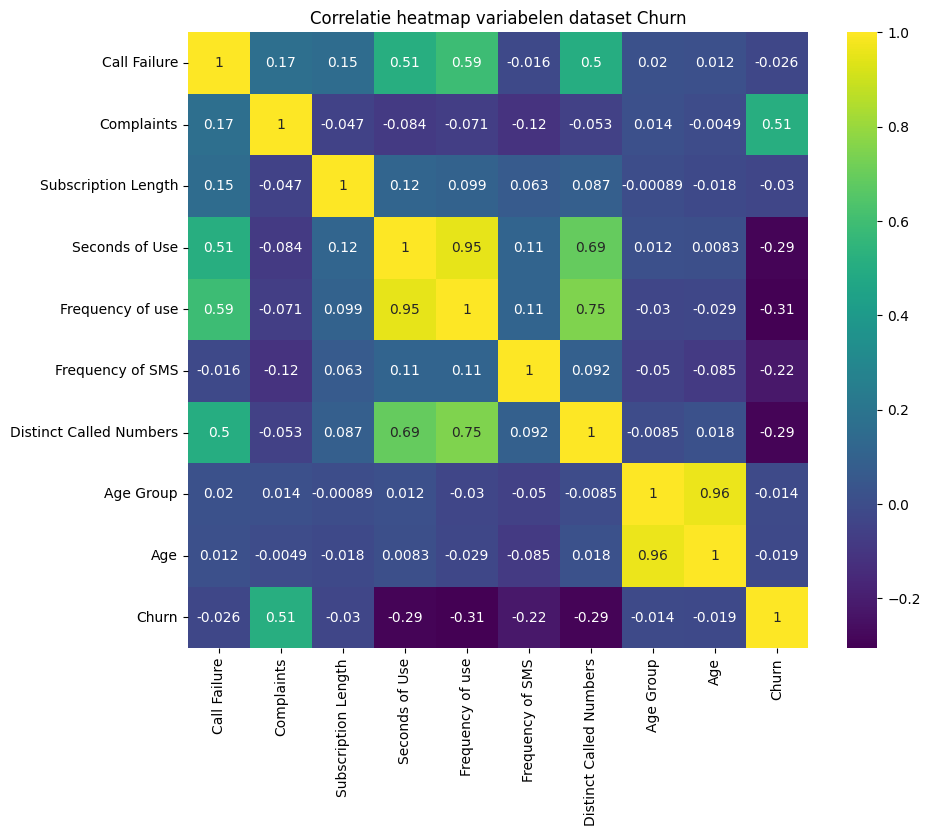

In [3]:
# We maken hier een heatmap aan van alle variabelen uit de train dataset afkomstig uit de dataset ganaamd churndata.
corr_matrix = data_train.corr()

plt.figure(figsize = (10,8))
sns.heatmap(corr_matrix, annot = True, cmap = "viridis")
plt.title("Correlatie heatmap variabelen dataset Churn")
plt.show()


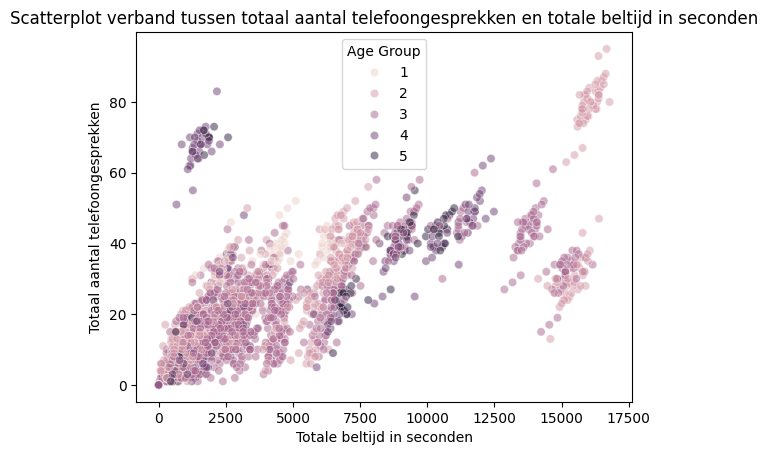

In [16]:
# We maken hier een scatterplot waarbij het totaal aantal telefoongesprekken tijdens de 9 maanden dataverzamling is uitgezet tegen de totale beltijd in seconden.
sns.scatterplot(x = "Seconds of Use", y = "Distinct Called Numbers", data = data_train, hue = "Age Group", alpha = 0.5)
plt.title("Scatterplot verband tussen totaal aantal telefoongesprekken en totale beltijd in seconden")
plt.xlabel('Totale beltijd in seconden')
plt.ylabel('Totaal aantal telefoongesprekken')
plt.show()

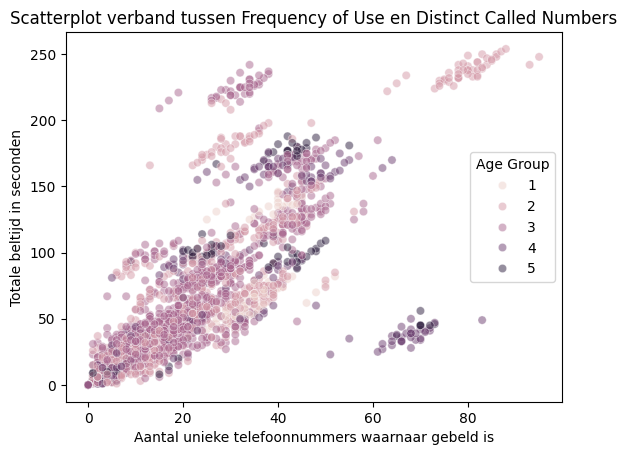

In [15]:
# We maken hier een scatterplot waarbij het totaal aantal telefoongesprekken tijdens de 9 maanden dataverzamling is uitgezet tegen het aantal unieke telefoonnummers waarnaar gebeld is.
sns.scatterplot(x = "Distinct Called Numbers", y = "Frequency of use", data = data_train, hue = "Age Group", alpha = 0.5)
plt.title("Scatterplot verband tussen Frequency of Use en Distinct Called Numbers")
plt.xlabel('Aantal unieke telefoonnummers waarnaar gebeld is')
plt.ylabel('Totale beltijd in seconden')
plt.show()


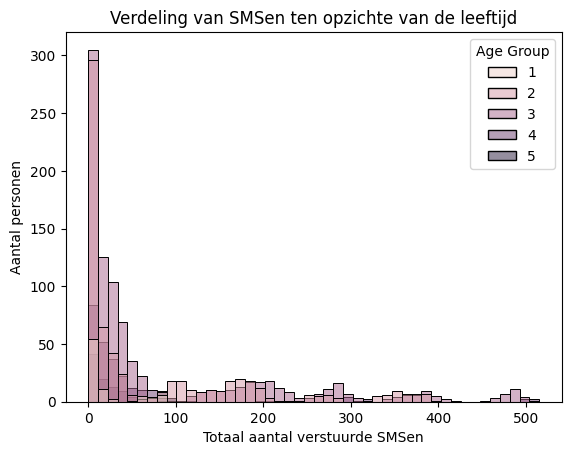

In [8]:
# We maken hier een scatterplot waarbij het totaal aantal personen met die leeftijd is uitgezet tegen het aantal verstuurde SMSen.
plt.title("Verdeling van SMSen ten opzichte van de leeftijd")
sns.histplot(data_train, x = 'Frequency of SMS', hue = 'Age Group')
plt.xlabel('Totaal aantal verstuurde SMSen')
plt.ylabel('Aantal personen')
plt.show()


<span style="font-size: 18px;"><b>Verdeling van aantal maanden abonnement</b></span>
In de figuur hieronder is een histogram te zien die de verdeling van het aantal maanden dat een klant een abonnement heeft per leeftijdsgroep, waarbij 1 = jong en 5 = oud. Opmerkelijk is dat de meeste klanten tussen de 30 en 40 maanden een abonnement hebben.

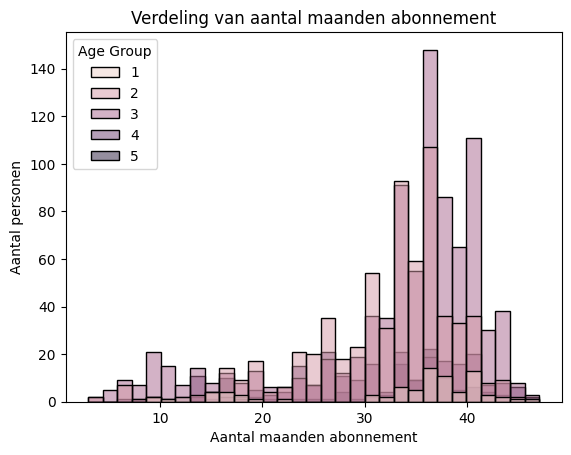

In [14]:
# We maken hier een histogram met de gegeven grafiek van de kansdichtheidsfunctie van het totaal aantal maanden dat een klant een abonnement heeft.
plt.title('Verdeling van aantal maanden abonnement')
sns.histplot(data_train, x = 'Subscription Length', hue = 'Age Group')
plt.xlabel('Aantal maanden abonnement')
plt.ylabel('Aantal personen')
plt.show()


<span style="font-size: 18px;"><b>Spreiding aantal maanden abonnement onder leeftijdsgroepen</b></span>
In de figuur hieronder zijn vijf boxplots weergegeven die de spreiding van het aantal maanden abonnement laten zien onder de vijf leeftijdsgroepen met 1 = jong en 5 = oud. Ook hier valt wederom uit te zien dat de meeste klanten een abonnement tussen de 30 en 40 maanden hebben.

Text(0.5, 1.0, 'Spreiding aantal maanden abonnement onder leeftijdsgroepen')

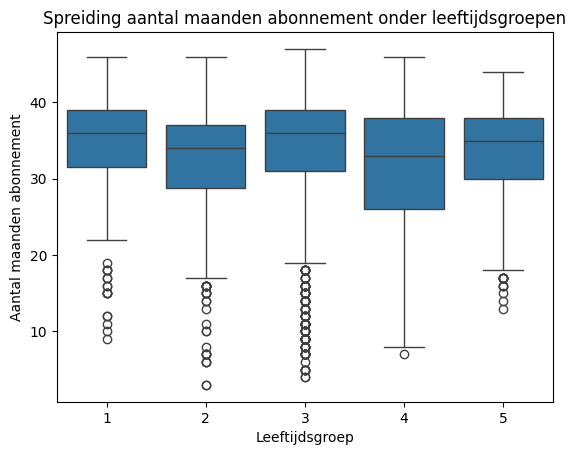

In [12]:
# We maken hier een boxplot waarbij we de spreiding van de abonnementlengte per leeftijdsgroep vergelijken, waarbij 1 = jong en 5 = oud.
duur_abonnement_spreiding = sns.boxplot(x = 'Age Group', y = 'Subscription Length', data = data_train)
plt.xlabel('Leeftijdsgroep')
plt.ylabel('Aantal maanden abonnement')
plt.title('Spreiding aantal maanden abonnement onder leeftijdsgroepen')


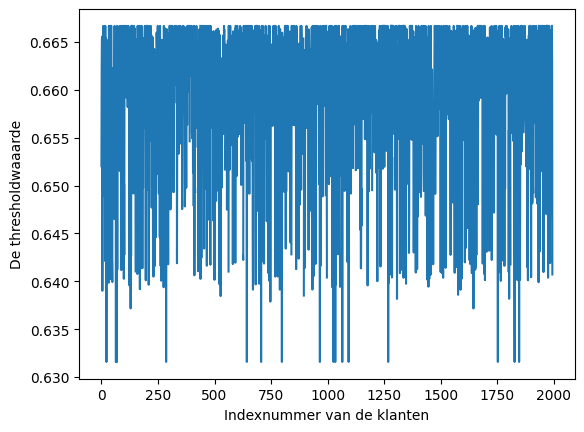

In [ ]:
# We maken hier een plot van de thresholds, waarbij per klant de berekende threshold laten zien.
W1 =  0.1 * data_train['Frequency of SMS']  + 0.3 * data_train['Seconds of Use'] / 60
W2 =  0.07 * data_train['Frequency of SMS'] + 0.2 * data_train['Seconds of Use'] / 60
   
threshold = (W2 - W1)/(0.75*W2 - W1)

plt.xlabel("Indexnummer van de klanten")
plt.ylabel("De thresholdwaaarde")
plt.title("Overstap naar tarief 2 per klant")
plt.plot(threshold)
